In [11]:
#  Load data and set up analysis switches
from pathlib import Path
import fusiproc_utils2 as fu
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting, image
from nilearn.signal import clean
from typing import List, Optional, Sequence, Tuple, Union


# -------- dataset paths -------
BASE = Path('/Users/clairenastaskin/data/sub-Forest001/2026-03-10/ev-069b0a51-b138-7b14-8000-3036c4fe4356/')
RUN  = 'pwd.nii'
PWD  = BASE / RUN
# SIDE = BASE / RUN.replace('_pwd.nii.gz', '_pwd.json')

# -------- analysis switches ----
CONF_USE = dict(
    motion_fsl24  = True,    # Friston24 (mutually exclusive with motion_6)
)

# --- temporal smoothing ------------------------------------------------------
SMOOTH_METHOD  = "none"          # {"none", "boxcar", "savgol"}
SMOOTH_WINDOW  = 3                 # if smoothing with boxcar (odd)

FD_THRESH     = 0.5          # mm
RADIUS_MM     = 50.0         # mm for FD sphere

# ---------------------------------------------------------------------------
# Build a short suffix that encodes the chosen method (+ key params)
# ---------------------------------------------------------------------------
if SMOOTH_METHOD == "none":
    smooth_tag = "_nosmooth"

elif SMOOTH_METHOD == "boxcar":
    smooth_tag = f"_boxcar{SMOOTH_WINDOW}"


def detect_motion_via_global(
        sig: np.ndarray, t_r: float, k: float = 4.0,
        high_pass: float = 0.01,
        y_lim: Optional[Tuple[float, float]] = None,
        frame_indices: Optional[np.ndarray] = None
) -> tuple[np.ndarray, np.ndarray, plt.Figure]:
    # High-pass filter (+ detrend) to remove slow drifts before thresholding
    sig_filt = clean(sig.reshape(-1, 1), detrend=True, high_pass=high_pass,
                     standardize=False, t_r=t_r).ravel()
    med = np.median(sig_filt)
    mad = np.median(np.abs(sig_filt - med))
    thr = med + k * mad
    bad = np.where(sig_filt > thr)[0]
    good = np.array([i for i in range(sig.size) if i not in bad], dtype=np.int64)

    x = frame_indices if frame_indices is not None else np.arange(len(sig))

    fig, axes = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

    # Top panel: input signal with outlier markers
    axes.plot(x, sig)
    for f in bad:
        axes.axvline(x[f], ls='--', c='r', alpha=.3)
    axes.set_title("Global signal with motion outliers")
    axes.set_ylabel("Average Intensity")
    if y_lim:
        axes.set_ylim(y_lim[0], y_lim[1])

    fig.tight_layout()
    return bad, good, fig

In [12]:
# convert nii file into nii.gz and save in BASE
gz_path = BASE / RUN.replace('.nii', '.nii.gz')
if not gz_path.exists():
    img = nib.load(PWD)
    data = img.get_fdata()
    nib.save(nib.Nifti1Image(data, img.affine), gz_path)
    print(f"Saved {gz_path}")
else:
    print(f"Already exists: {gz_path}")
PWD = gz_path

Already exists: /Users/clairenastaskin/data/sub-Forest001/2026-03-10/ev-069b0a51-b138-7b14-8000-3036c4fe4356/pwd.nii.gz


In [13]:
# Load ARIA logs and convert to numpy array, then save as JSON
import json

logs_path = Path(BASE, 'logs.parquet')
json_out = logs_path.with_suffix('.json')

if not json_out.exists():
    logs_df = pd.read_parquet(logs_path)
    logs_df.to_json(json_out, orient='columns', indent=2)
    print(f"Saved JSON to {json_out}")
else:
    logs_df = pd.read_json(json_out)
    print(f"Already exists: {json_out}")

logs_arr = logs_df.to_numpy()

SIDE = BASE / 'logs.json'
with open(SIDE, 'r') as f:
    sidecar = json.load(f)
volume_timing_ns = sidecar["time_ns"]["3"] -  sidecar["time_ns"]["2"]
volume_timing_s = volume_timing_ns / 1e9 # convert from nanoseconds to seconds
t_r = volume_timing_s
np.save(BASE / "t_r.npy", t_r)

Already exists: /Users/clairenastaskin/data/sub-Forest001/2026-03-10/ev-069b0a51-b138-7b14-8000-3036c4fe4356/logs.json


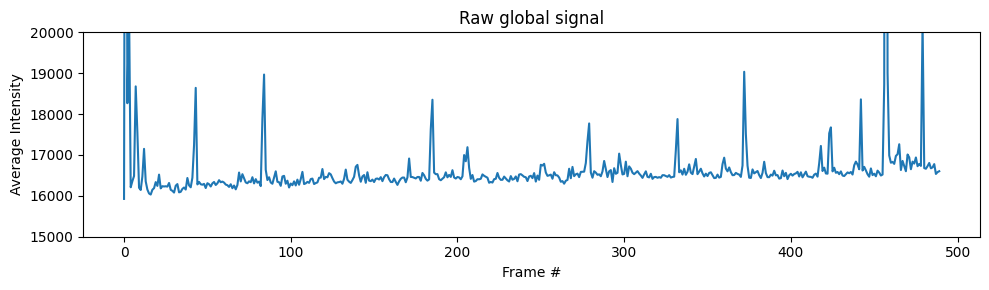

In [14]:
#  Load data and plot raw global signal
data, affine, _ = fu.load_fusi_nifti(PWD)
mask = fu.nan_mask(data)
mask_path = fu.save_nifti(mask.astype(np.uint8), affine,
                          PWD.with_name(RUN.replace('_pwd', '_mask')))

y_lim = [15000, 20000]  # Set the y-axis limits

gs = fu.global_signal(data)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(gs)
ax.set_title("Raw global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")
ax.set_ylim(y_lim[0], y_lim[1])
plt.tight_layout()
plt.show()

Frames above 1.7e+04: 31
Frame indices: [  1   2   3   7   8  12  42  43  83  84 184 185 206 278 279 297 331 332
 372 373 418 423 424 442 456 457 458 464 465 470 479]
Also removing frame 0 (always artifact) → total skip so far: 32


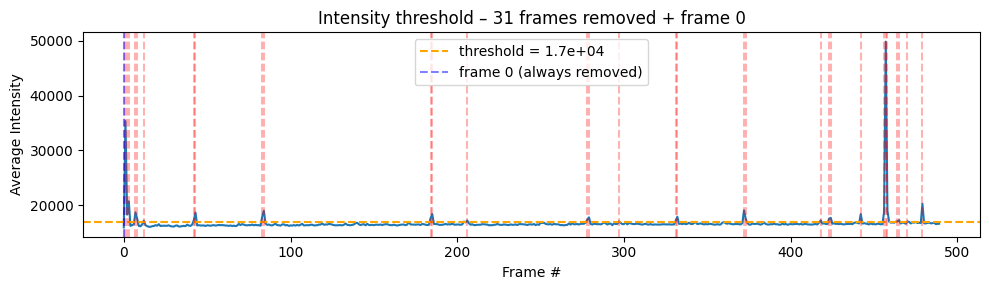

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Remove frames above an arbitrary intensity threshold
# ─────────────────────────────────────────────────────────────────────────────
INTENSITY_THRESH = 1.7e4   # <-- adjust this based on the raw plot above

bad_intensity = np.where(gs > INTENSITY_THRESH)[0]
skip = set(int(i) for i in bad_intensity)
skip.add(0)  # Always remove first frame (acquisition artifact)

print(f"Frames above {INTENSITY_THRESH:.1e}: {len(bad_intensity)}")
print(f"Frame indices: {bad_intensity}")
print(f"Also removing frame 0 (always artifact) → total skip so far: {len(skip)}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(gs)
ax.axhline(INTENSITY_THRESH, ls='--', c='orange', label=f'threshold = {INTENSITY_THRESH:.1e}')
for f in bad_intensity:
    ax.axvline(f, ls='--', c='r', alpha=.3)
ax.axvline(0, ls='--', c='b', alpha=.5, label='frame 0 (always removed)')
ax.set_title(f"Intensity threshold – {len(bad_intensity)} frames removed + frame 0")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")
# ax.set_ylim(y_lim[0], y_lim[1])
ax.legend()
plt.tight_layout()
plt.show()

Motion outlier frames: 11
Total skipped frames (intensity + motion): 43


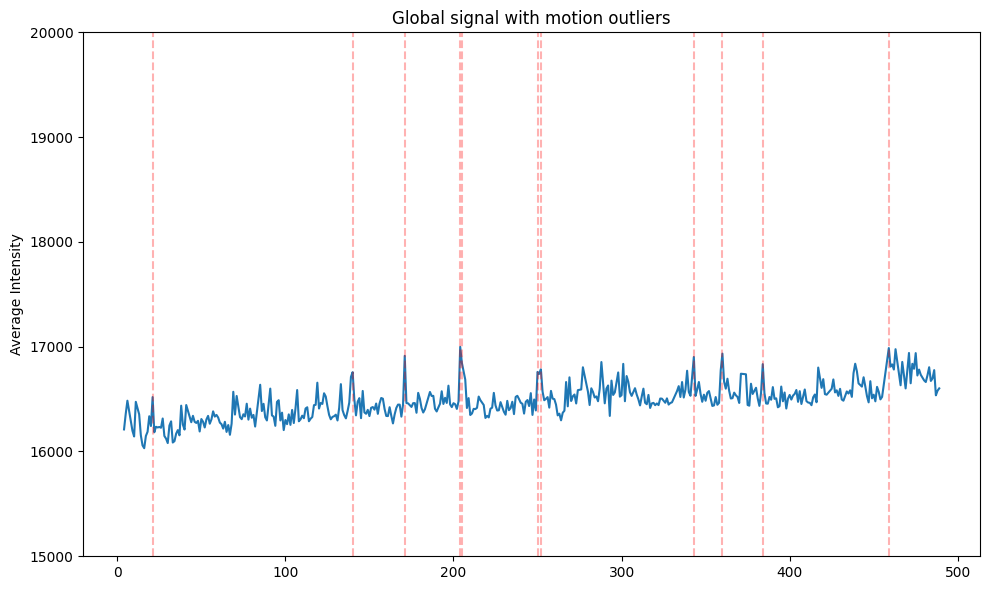

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Motion outlier detection (on signal with extreme frames removed)
# ─────────────────────────────────────────────────────────────────────────────
keep_mask = np.ones(len(gs), dtype=bool)
keep_mask[list(skip)] = False
gs_clean = gs[keep_mask]
kept_frames = np.where(keep_mask)[0]

bad_clean, good_clean, fig = detect_motion_via_global(
    gs_clean, t_r, k=5.0, frame_indices=kept_frames, y_lim=y_lim)

# Map back to original frame indices
bad_gs = kept_frames[bad_clean]
skip.update(int(i) for i in bad_gs)

fig.savefig(BASE / "global_signal_with_masked_frame.png")
print(f"Motion outlier frames: {len(bad_gs)}")
print(f"Total skipped frames (intensity + motion): {len(skip)}")

In [17]:
#  Rigid registration
# ------------------------------------------------------------------
# Rigid registration
# ------------------------------------------------------------------
registration_path = BASE / "registration"

if not registration_path.exists():
    registration_path.mkdir(exist_ok=True)
    
    reg, rigid, metric, stop, kept_idx = fu.register_3d_image_stack(
            np.where(np.isfinite(data), data, 0),
            reference='median',
            spacing=np.linalg.norm(affine[:3, :3], axis=0),
            skip_indices=skip,
            mask=mask,
            verbose=True)

    # Save the registration outputs
    np.save(registration_path / "reg.npy", reg)
    np.save(registration_path / "rigid.npy", rigid)
    np.save(registration_path / "metric.npy", metric)
    np.save(registration_path / "stop.npy", stop)
    np.save(registration_path / "kept_idx.npy", kept_idx)
    np.save(registration_path / "skip.npy", skip)
    # ---- Doppler movie -------------------------------------------------
    html = fu.save_doppler_movie(reg, registration_path/"Doppler_movie_after_rigid_registration.mp4")
    html  # renders in Jupyter

else:
    reg = np.load(registration_path / "reg.npy")
    rigid = np.load(registration_path / "rigid.npy")
    metric = np.load(registration_path / "metric.npy")
    stop = np.load(registration_path / "stop.npy")
    kept_idx = np.load(registration_path / "kept_idx.npy")



[frame    4] metric = -8.276321e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 10 iterations. Gradient magnitude (5.7657e-05) is less than gradient magnitude tolerance (0.0001).
[frame    5] metric = -8.261054e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 11 iterations. Gradient magnitude (7.66436e-05) is less than gradient magnitude tolerance (0.0001).
[frame    6] metric = -7.801451e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 13 iterations. Gradient magnitude (1.96181e-05) is less than gradient magnitude tolerance (0.0001).
[frame    9] metric = -8.376605e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 12 iterations. Gradient magnitude (1.72121e-05) is less than gradient magnitude tolerance (0.0001).
[frame   10] metric = -8.587966e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance m

/Users/clairenastaskin/Documents/Anise/Experiments/fusiproc_utils2.py:439: RuntimeWarning: divide by zero encountered in log10
  data_db = 10*np.log10(reg_data)
Animation size has reached 21089285 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


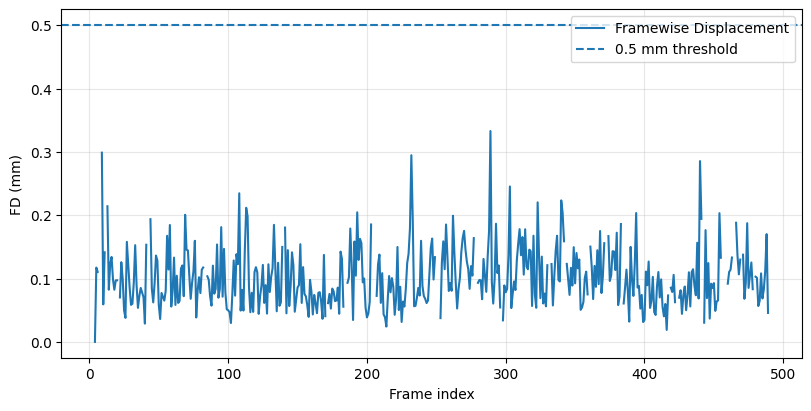

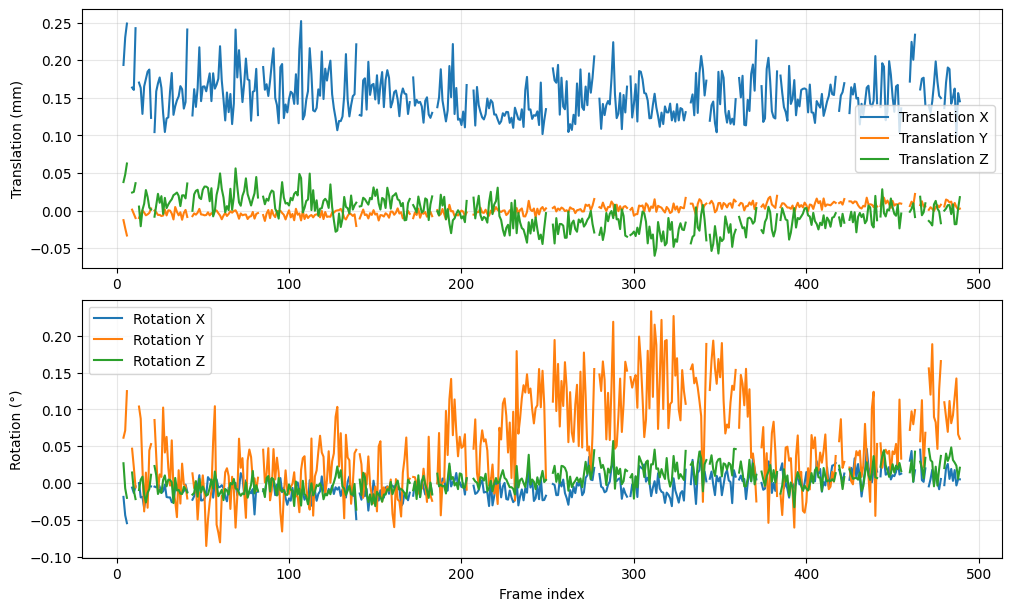

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5 – FD outliers, censor list, NaN‑padding
# ─────────────────────────────────────────────────────────────────────────────
n_frames = data.shape[-1]

# 1. FD on the gap‑free series (after GS censoring) ---------------------------
fd = fu.framewise_displacement(rigid, radius_mm=RADIUS_MM)

fd_full = np.full(n_frames, np.nan)
fd_full[kept_idx] = fd

bad_fd = fu.plot_fd(fd_full, FD_THRESH, BASE/"framewise_displacement.png")
np.savetxt(BASE/"fd_over_0p5_indices.txt", bad_fd, fmt='%d')

# 2. update global censor list ------------------------------------------------
skip.update(int(i) for i in bad_fd)

# 3. remove newly censored frames from the registration outputs ---------------
keep_after_all = [i for i in kept_idx if i not in skip]     # T indices
sel            = np.isin(kept_idx, keep_after_all)          # boolean mask

reg_use    = reg[...,  sel]           # (x,y,z,T)
rigid_use  = rigid[:,  sel]           # (6,T)
metric_use = metric[   sel]           # (T,)
stop_use   = [s for s, ok in zip(stop, sel) if ok]

# 4. create full‑length NaN‑padded arrays ------------------------------------
retained = keep_after_all                                 # same T indices
reg_full, rigid_full, metric_full, stop_full = fu.reinstate_nans(
        reg_use, rigid_use, metric_use, stop_use,
        n_frames, retained)

fu.plot_registration_parameters(rigid_full, registration_path/"registration.png")


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Sample mask, temporal smoothing, confounds (length‑matched)
# ─────────────────────────────────────────────────────────────────────────────
good_all    = np.array(retained, dtype=int)   # final list of frames to keep
sample_mask = good_all                        # passed to Nilearn

# -- temporal smoothing -------------------------------------------------------
if   SMOOTH_METHOD == "none":
    smoothed = reg_full.copy()

elif SMOOTH_METHOD == "boxcar":
    # Apply boxcar (moving average) smoothing: replaces each frame with the average across a sliding window.
    smoothed = fu.boxcar_smooth(reg_full, SMOOTH_WINDOW)


clean_img = nib.Nifti1Image(np.nan_to_num(smoothed), affine)
clean_img.to_filename(BASE/"fusi_run_clean.nii.gz")
fu.save_nifti(np.mean(clean_img.get_fdata(), axis=-1), affine, BASE/"fusi_run_clean_mean.nii.gz")

PosixPath('/Users/clairenastaskin/data/sub-Forest001/2026-03-10/ev-069b0a51-b138-7b14-8000-3036c4fe4356/fusi_run_clean_mean.nii.gz')

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_3782/3620151577.py:15: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  filtered_2d = signal_clean(voxels_2d, high_pass=0.01, t_r=t_r, detrend=False)


High-pass filtered data saved – 447 retained frames, cutoff = 0.01 Hz


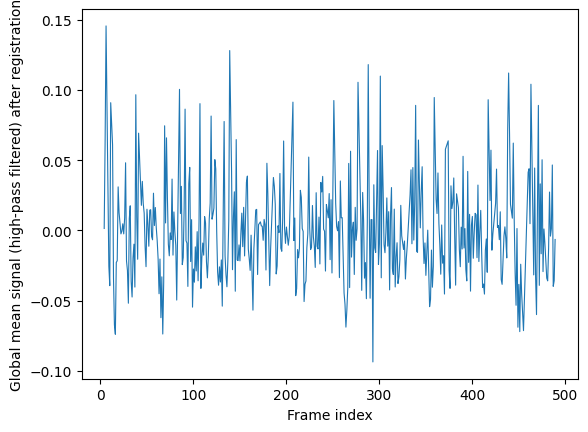

In [20]:
# Voxelwise high-pass filter (cutoff = 0.01 Hz)

from nilearn.signal import clean as signal_clean

fusi_data = clean_img.get_fdata()                        # (x, y, z, T)
nx, ny, nz, nt = fusi_data.shape

# Extract only retained frames (avoid filtering the zero-padded gaps)
good_data = fusi_data[..., sample_mask]                  # (x, y, z, n_good)

# Reshape to (n_good, n_voxels) – the layout nilearn.signal.clean expects
voxels_2d = good_data.reshape(-1, len(sample_mask)).T    # (n_good, n_voxels)

# High-pass filter each voxel's timeseries at 0.01 Hz
filtered_2d = signal_clean(voxels_2d, high_pass=0.01, t_r=t_r, detrend=False)

# Place filtered frames back into the full-length array
filtered_data = np.zeros_like(fusi_data)
filtered_data[..., sample_mask] = filtered_2d.T.reshape(nx, ny, nz, len(sample_mask))

# Update clean_img 
clean_img = nib.Nifti1Image(filtered_data, affine)
clean_img.to_filename(BASE / "fusi_run_clean_highpass.nii.gz")
print(f"High-pass filtered data saved – {len(sample_mask)} retained frames, cutoff = 0.01 Hz")

global_mean_filtered = np.mean(filtered_data, axis=(0,1,2))
fig, ax = plt.subplots()
ax.plot(sample_mask, global_mean_filtered[sample_mask], linewidth=0.8)
ax.set_xlabel("Frame index")
ax.set_ylabel("Global mean signal (high-pass filtered) after registration")
fig.savefig(BASE / "filtered_global_mean.png", dpi=150)
plt.show()

In [21]:
# Import events.tsv 
import pandas as pd
import os

if os.path.exists(BASE / 'task_events.tsv'):
    events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
else:
    task_path = list(BASE.glob('*events.tsv'))[0]
    events = pd.read_csv(task_path, sep='\t')

# events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
events["trial_type"]

0    video
1    video
2    video
3    video
4    video
5    video
Name: trial_type, dtype: object

In [22]:
# Explainable Variance – segment epochs

vol_times = (logs_arr[:,0] - logs_arr[0,0])/ 1e9 + t_r/2  # convert to seconds relative to start of run

# Load BBC events (6 repetitions)
ev_dir = BASE 
ev_path = list(ev_dir.glob('*events.tsv'))[0]
bbc_events = pd.read_csv(ev_path, sep='\t')
print(bbc_events[['onset', 'duration', 'trial_type']].to_string())
print()

# For each block, find the closest fUSI volume to the onset/offset
epochs = []
for _, row in bbc_events.iterrows():
    onset  = row['onset']
    offset = onset + row['duration']
    start_idx = np.argmin(np.abs(vol_times - onset))
    end_idx   = np.argmin(np.abs(vol_times - offset))
    epochs.append((start_idx, end_idx))
    print(f"  Onset {onset:8.1f}s → vol {start_idx:5d} (t={vol_times[start_idx]:.1f}s)  |  "
          f"Offset {offset:8.1f}s → vol {end_idx:5d} (t={vol_times[end_idx]:.1f}s)  |  "
          f"n_vols = {end_idx - start_idx}")

# ── Select a subset of epochs ───────────────────────────────────────────────
# Set to None to use all epochs, or specify a list of epoch indices (0-based)
# e.g. [1, 2, 3, 4, 5] to skip epoch 0
EPOCH_SELECTION = None #[1, 2, 4, 5]

if EPOCH_SELECTION is not None:
    epochs = [epochs[i] for i in EPOCH_SELECTION]
    print(f"\n→ Using {len(epochs)} selected epochs: {EPOCH_SELECTION}")
else:
    print(f"\n→ Using all {len(epochs)} epochs")

n_vols_per_epoch = min(end - start for start, end in epochs)
print(f"Using {n_vols_per_epoch} volumes per epoch (trimmed to shortest)")

        onset  duration trial_type
0   -1.077339       151      video
1  154.294085       150      video
2  309.165754       150      video
3  464.155558       150      video
4  619.155488       150      video
5  774.156739       150      video

  Onset     -1.1s → vol     0 (t=1.0s)  |  Offset    149.9s → vol    78 (t=149.3s)  |  n_vols = 78
  Onset    154.3s → vol    81 (t=155.0s)  |  Offset    304.3s → vol   160 (t=305.2s)  |  n_vols = 79
  Onset    309.2s → vol   162 (t=309.0s)  |  Offset    459.2s → vol   241 (t=459.2s)  |  n_vols = 79
  Onset    464.2s → vol   244 (t=464.9s)  |  Offset    614.2s → vol   322 (t=613.2s)  |  n_vols = 78
  Onset    619.2s → vol   325 (t=619.0s)  |  Offset    769.2s → vol   404 (t=769.2s)  |  n_vols = 79
  Onset    774.2s → vol   407 (t=774.9s)  |  Offset    924.2s → vol   486 (t=925.1s)  |  n_vols = 79

→ Using all 6 epochs
Using 78 volumes per epoch (trimmed to shortest)


In [23]:
# Explainable Variance 
import scipy.stats
from scipy.ndimage import binary_erosion

nx, ny, nz, nt = reg_full.shape

# ── Time window (relative to epoch onset) ────────────────────────────────────
# Set to None to use the full epoch, or (start_s, end_s) to restrict
# e.g. (45, 120) to only use 45s–120s within each epoch
TIME_WINDOW = None  # (45, 120)  # seconds relative to epoch onset

# Minimum fraction of valid (non-NaN) timepoints required per epoch per voxel
MIN_VALID_FRAC = 0.5

# Number of voxels to erode from the mask border (0 = no erosion)
MASK_ERODE_VOXELS = 5

# 1. Voxel mask: voxels that are ALWAYS inside the FOV across all retained frames
#    (border voxels that move in/out during registration are excluded)
retained_data = reg_full[..., sample_mask]
voxel_mask = np.all(np.isfinite(retained_data), axis=-1)   # (nx, ny, nz)

# Erode the mask to remove border voxels
if MASK_ERODE_VOXELS > 0:
    n_before = voxel_mask.sum()
    voxel_mask = binary_erosion(voxel_mask, iterations=MASK_ERODE_VOXELS)
    print(f"Mask erosion: {MASK_ERODE_VOXELS} voxels  →  {n_before} → {voxel_mask.sum()} valid voxels")

valid_idx  = np.where(voxel_mask.ravel())[0]
n_valid    = len(valid_idx)
print(f"Valid voxels (after erosion): {n_valid} / {nx*ny*nz}")

# 2. Extract epochs – only valid voxels, keep NaNs for censored frames
N_rep = len(epochs)
Y = np.empty((N_rep, n_vols_per_epoch, n_valid))
for i, (start, _) in enumerate(epochs):
    epoch_data = reg_full[..., start:start + n_vols_per_epoch]   # (nx,ny,nz,n_vols)
    Y[i] = epoch_data.reshape(-1, n_vols_per_epoch)[valid_idx].T # (n_vols, n_valid)

# 3. Apply time window (restrict to a sub-range within each epoch)
epoch_times = np.arange(n_vols_per_epoch) * t_r
time_use = np.ones(n_vols_per_epoch, dtype=bool)
if TIME_WINDOW is not None:
    t_start, t_end = TIME_WINDOW
    time_use = (epoch_times >= t_start) & (epoch_times <= t_end)
    print(f"Time window: {t_start}s – {t_end}s  →  {time_use.sum()} volumes in range")

Y = Y[:, time_use, :]  # (N_rep, T_window, V)
epoch_times_use = epoch_times[time_use]
n_timepoints = Y.shape[1]

# 4. NaN-aware z-score: (x - nanmean) / nanstd per (epoch, voxel)
Y_mean = np.nanmean(Y, axis=1, keepdims=True)   # (N_rep, 1, V)
Y_std  = np.nanstd(Y, axis=1, keepdims=True, ddof=0)  # (N_rep, 1, V)
Y_std[Y_std == 0] = np.nan  # avoid division by zero
Y_ev = (Y - Y_mean) / Y_std  # (N_rep, T, V) – NaNs remain as NaN

# Count valid timepoints per (epoch, voxel) and mask voxels with too few
n_valid_per_epoch = np.sum(np.isfinite(Y_ev), axis=1)  # (N_rep, V)
min_valid_count = int(MIN_VALID_FRAC * n_timepoints)
bad_voxel_mask = np.any(n_valid_per_epoch < min_valid_count, axis=0)  # (V,)
Y_ev[:, :, bad_voxel_mask] = np.nan

n_valid_total = np.sum(np.isfinite(Y), axis=1).mean(axis=0).mean()
print(f"Timepoints per epoch: {n_timepoints} (avg {n_valid_total:.0f} valid after censoring)")
print(f"Voxels excluded (< {MIN_VALID_FRAC*100:.0f}% valid): {bad_voxel_mask.sum()} / {n_valid}")
print(f"Y_ev shape: {Y_ev.shape}  (repeats x timepoints x voxels)")

# 5. NaN-aware Explainable Variance (Gallant lab method)
mean_var = np.nanvar(Y_ev, axis=1, dtype=np.float64, ddof=1)   # (N_rep, V)
mean_var = np.nanmean(mean_var, axis=0)                         # (V,)

var_mean = np.nanmean(Y_ev, axis=0)                             # (T, V)
var_mean = np.nanvar(var_mean, axis=0, dtype=np.float64, ddof=1)  # (V,)

ev_gallant = var_mean / mean_var                                # (V,)
ev_gallant = ev_gallant - (1 - ev_gallant) / (N_rep - 1)       # bias correction

ev_gallant_vol = np.full(nx * ny * nz, np.nan)
ev_gallant_vol[valid_idx] = ev_gallant
ev_gallant_vol = ev_gallant_vol.reshape(nx, ny, nz)

ev_vol = ev_gallant_vol
ev = ev_gallant

mean_response = np.nanmean(Y_ev, axis=0)  # (T, V) – for plotting in cell-14

print(f"\nEV  min: {np.nanmin(ev):.4f}   median: {np.nanmedian(ev):.4f}   max: {np.nanmax(ev):.4f}")

Mask erosion: 5 voxels  →  1265904 → 930744 valid voxels
Valid voxels (after erosion): 930744 / 1265904
Timepoints per epoch: 78 (avg 71 valid after censoring)
Voxels excluded (< 50% valid): 258684 / 930744
Y_ev shape: (6, 78, 930744)  (repeats x timepoints x voxels)


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_3782/4143800535.py:70: RuntimeWarning: Degrees of freedom <= 0 for slice.
  mean_var = np.nanvar(Y_ev, axis=1, dtype=np.float64, ddof=1)   # (N_rep, V)
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_3782/4143800535.py:71: RuntimeWarning: Mean of empty slice
  mean_var = np.nanmean(mean_var, axis=0)                         # (V,)
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_3782/4143800535.py:73: RuntimeWarning: Mean of empty slice
  var_mean = np.nanmean(Y_ev, axis=0)                             # (T, V)
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_3782/4143800535.py:74: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_mean = np.nanvar(var_mean, axis=0, dtype=np.float64, ddof=1)  # (V,)



EV  min: -0.1082   median: 0.0241   max: 0.2019


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_3782/4143800535.py:86: RuntimeWarning: Mean of empty slice
  mean_response = np.nanmean(Y_ev, axis=0)  # (T, V) – for plotting in cell-14


Saved: /Users/clairenastaskin/data/sub-Forest001/2026-03-10/ev-069b0a51-b138-7b14-8000-3036c4fe4356/explainable_variance_map.nii.gz
Saved: /Users/clairenastaskin/data/sub-Forest001/2026-03-10/ev-069b0a51-b138-7b14-8000-3036c4fe4356/explainable_variance_map.npy


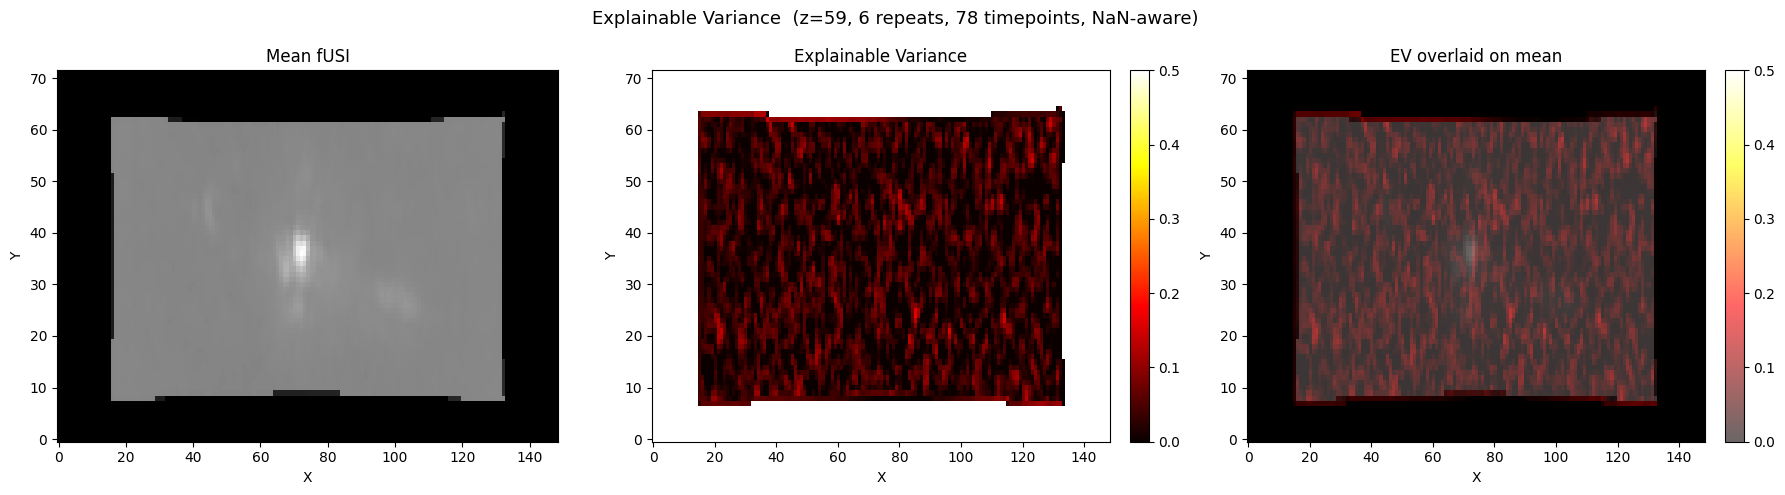

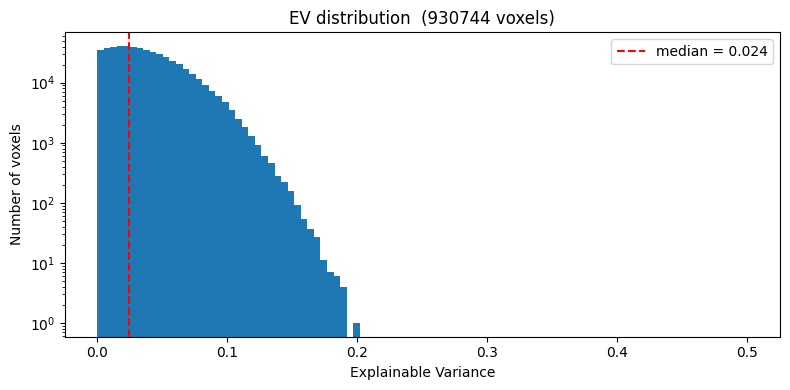

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Explainable Variance – save and plot
# ─────────────────────────────────────────────────────────────────────────────

# Save EV map as NIfTI and numpy
ev_img = nib.Nifti1Image(ev_vol, affine)
ev_img.to_filename(BASE / "explainable_variance_map.nii.gz")
np.save(BASE / "explainable_variance_map.npy", ev_vol)
print(f"Saved: {BASE / 'explainable_variance_map.nii.gz'}")
print(f"Saved: {BASE / 'explainable_variance_map.npy'}")

# ── Slice views ──────────────────────────────────────────────────────────────
mean_data = nib.load(BASE / "fusi_run_clean_mean.nii.gz").get_fdata()
mid_z = nz // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(mean_data[:, :, mid_z].T, origin='lower', cmap='gray', aspect='auto')
axes[0].set_title("Mean fUSI")

im1 = axes[1].imshow(ev_vol[:, :, mid_z].T, origin='lower', cmap='hot',
                      vmin=0, vmax=0.5, aspect='auto')
axes[1].set_title("Explainable Variance")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(mean_data[:, :, mid_z].T, origin='lower', cmap='gray', aspect='auto')
im2 = axes[2].imshow(ev_vol[:, :, mid_z].T, origin='lower', cmap='hot',
                      alpha=0.6, vmin=0, vmax=0.5, aspect='auto')
axes[2].set_title("EV overlaid on mean")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("X"); ax.set_ylabel("Y")
fig.suptitle(f"Explainable Variance  (z={mid_z}, {N_rep} repeats, "
             f"{n_timepoints} timepoints, NaN-aware)", fontsize=13)
fig.tight_layout()
fig.savefig(BASE / "explainable_variance_map.png", dpi=300)
plt.show()

# ── Histogram ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ev[np.isfinite(ev)], bins=np.linspace(0, 0.5, 100), log=True, edgecolor='none')
ax.set_xlabel("Explainable Variance")
ax.set_ylabel("Number of voxels")
ax.set_title(f"EV distribution  ({n_valid} voxels)")
ax.axvline(np.nanmedian(ev), ls='--', c='r',
           label=f'median = {np.nanmedian(ev):.3f}')
ax.legend()
fig.tight_layout()
fig.savefig(BASE / "explainable_variance_histogram.png", dpi=150)
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Overlaid timecourses: highest vs lowest EV voxels
# ─────────────────────────────────────────────────────────────────────────────
# Time axis – all timepoints in the window (NaN gaps will break the lines naturally)
t_sec = epoch_times_use

# Find best and worst voxels (nanarg* to skip NaN from 0/0 division)
best_vox = np.nanargmax(ev)
worst_vox = np.nanargmin(ev)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# ── Highest EV ───────────────────────────────────────────────────────────────
for rep in range(N_rep):
    axes[0].plot(t_sec, Y_ev[rep, :, best_vox], alpha=0.6, label=f'rep {rep+1}')
axes[0].plot(t_sec, mean_response[:, best_vox], 'k-', lw=2, label='mean')
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"Highest EV voxel  (EV = {ev[best_vox]:.4f})")
axes[0].legend(loc='upper right', ncol=4, fontsize=8)

# ── Lowest EV ────────────────────────────────────────────────────────────────
for rep in range(N_rep):
    axes[1].plot(t_sec, Y_ev[rep, :, worst_vox], alpha=0.6, label=f'rep {rep+1}')
axes[1].plot(t_sec, mean_response[:, worst_vox], 'k-', lw=2, label='mean')
axes[1].set_ylabel("Intensity")
axes[1].set_xlabel("Time (s)")
axes[1].set_title(f"Lowest EV voxel  (EV = {ev[worst_vox]:.4f})")
axes[1].legend(loc='upper right', ncol=4, fontsize=8)

fig.tight_layout()
fig.savefig(BASE / "ev_timecourses_best_worst.png", dpi=150)
plt.show()